# 📊 Portfolio Analytics & Risk Engine

This project develops a comprehensive portfolio analytics and risk modelling engine using Python, combining core concepts from quantitative finance and statistics.

It integrates:
- Monte Carlo Simulation to model uncertainty in returns  
- Efficient Frontier analysis to identify optimal portfolios  
- Value-at-Risk (VaR) and Conditional VaR (CVaR) for downside risk estimation  
- Maximum Drawdown to measure peak-to-trough losses  

The objective is to move beyond basic return analysis and build a system that evaluates portfolios under real-world uncertainty, risk, and market dynamics.



In [1]:
# Install required package
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## 📥 Data Collection

We collect historical stock price data using Yahoo Finance.
These assets will form our portfolio universe.

In [3]:
stocks = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS",
          "ICICIBANK.NS","ITC.NS","HINDUNILVR.NS","SBIN.NS",
          "LT.NS","BHARTIARTL.NS"]

data = yf.download(stocks, start="2018-01-01", end="2024-12-31")

prices = data["Close"]

prices.head()

/tmp/ipykernel_3256/2633616214.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2018-01-01", end="2024-12-31")
[*********************100%***********************]  10 of 10 completed


Ticker,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2018-01-01,453.573090,432.689056,1184.235229,298.055023,415.244263,183.645401,1118.449463,401.864807,283.366302,1083.771484
2018-01-02,443.821136,436.853760,1179.038452,297.478699,413.697418,182.560181,1108.735229,402.483215,279.813843,1077.872681
2018-01-03,445.238831,432.257385,1189.387939,302.569611,410.322571,182.840240,1131.402100,404.095551,279.444733,1080.924438
2018-01-04,449.362976,433.948944,1191.061279,302.281403,407.952209,183.120270,1167.243530,406.525085,284.658081,1088.482300
2018-01-05,463.969452,434.812195,1194.848755,300.552429,406.586121,184.065475,1166.534180,407.828217,282.674255,1101.631836


## 📈 Return & Risk Metrics

We compute:
- Daily returns
- Mean returns
- Covariance matrix

These are the building blocks of portfolio analysis.

In [4]:
returns = prices.pct_change().dropna()

mean_returns = returns.mean()

cov_matrix = returns.cov()

## 🔗 Correlation Analysis

Correlation helps us understand how assets move relative to each other.
Diversification benefits arise when correlations are low.

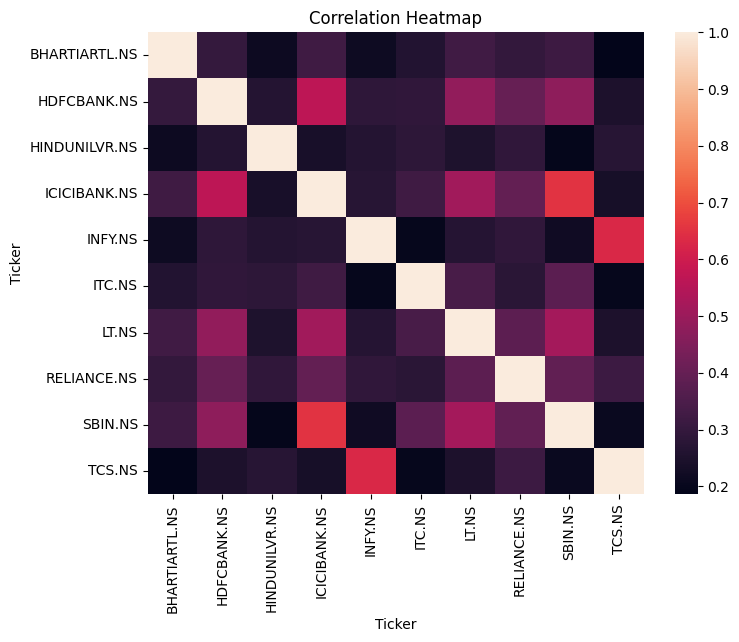

In [5]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

## 🧮 Portfolio Construction

We construct an equally weighted portfolio and calculate:
- Expected return
- Portfolio volatility

This is based on portfolio theory principles.

In [6]:
num_assets = len(returns.columns)

weights = np.repeat(1/num_assets, num_assets)

portfolio_return = np.sum(mean_returns * weights) * 252

portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(cov_matrix * 252, weights))
)

print("Expected Return:", portfolio_return)
print("Volatility:", portfolio_volatility)

Expected Return: 0.19894908055436375
Volatility: 0.17348664674800376


## Now we generate thousands of random portfolios with different weight combinations.

This helps us explore the full risk-return landscape.

In [7]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):

    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    weights_record.append(weights)

    port_return = np.sum(mean_returns * weights) * 252

    port_vol = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    )

    results[0,i] = port_return
    results[1,i] = port_vol

## 📊 Efficient Frontier & Optimal Portfolio

We calculate the Sharpe ratio to identify:
- Best risk-adjusted portfolio
- Minimum risk portfolio

In [8]:
results[2,:] = results[0,:] / results[1,:]

max_sharpe_idx = np.argmax(results[2])

max_return = results[0, max_sharpe_idx]
max_vol = results[1, max_sharpe_idx]

min_vol_idx = np.argmin(results[1])

min_return = results[0, min_vol_idx]
min_volatility = results[1, min_vol_idx]

## 📉 Efficient Frontier Visualization

Each point represents a portfolio.

We highlight:
- ⭐ Maximum Sharpe portfolio
- ❌ Minimum volatility portfolio

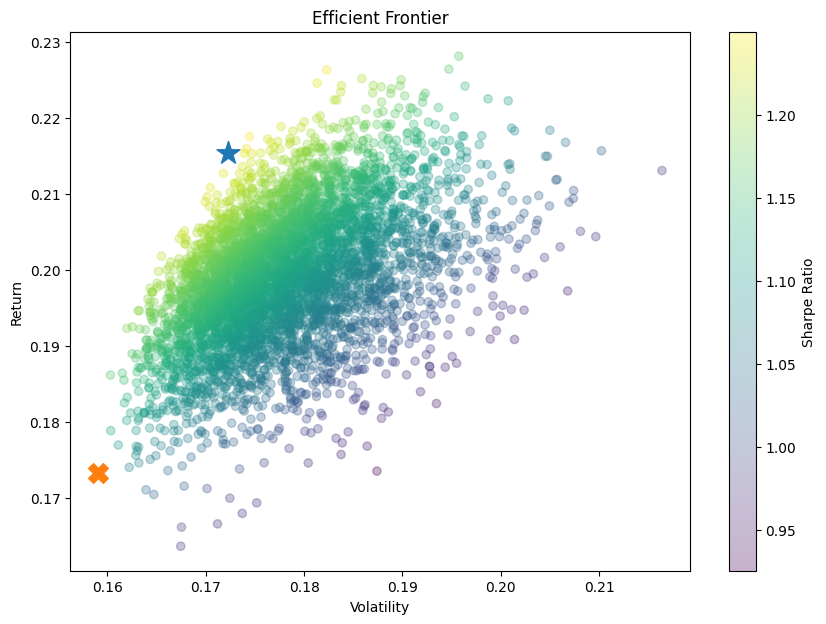

In [9]:
plt.figure(figsize=(10,7))

plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap="viridis", alpha=0.3)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(max_vol, max_return, marker="*", s=300)

plt.scatter(min_volatility, min_return, marker="X", s=200)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.show()

## 📊 Optimal Portfolio Allocation

We extract the weights of the portfolio with the highest Sharpe ratio.

In [10]:
optimal_weights = weights_record[max_sharpe_idx]

pd.Series(optimal_weights, index=returns.columns)

,0
Ticker,
BHARTIARTL.NS,0.149410
HDFCBANK.NS,0.006342
HINDUNILVR.NS,0.036689
ICICIBANK.NS,0.118969
INFY.NS,0.194756
ITC.NS,0.184300
LT.NS,0.053911
RELIANCE.NS,0.043146
SBIN.NS,0.017470


## 🔮 Future Portfolio Simulation using Monte Carlo method

Using Monte Carlo simulation, we generate possible future paths
of the portfolio value over time.

In [11]:
mu = max_return
sigma = max_vol

num_simulations = 1000
num_days = 252
initial_investment = 100000

simulation_results = np.zeros((num_days, num_simulations))

for i in range(num_simulations):

    daily_returns = np.random.normal(
        mu/252,
        sigma/np.sqrt(252),
        num_days
    )

    portfolio_path = initial_investment * np.cumprod(1 + daily_returns)

    simulation_results[:, i] = portfolio_path

## 📈 Monte Carlo Simulation Paths

Each line represents one possible future trajectory of portfolio value.

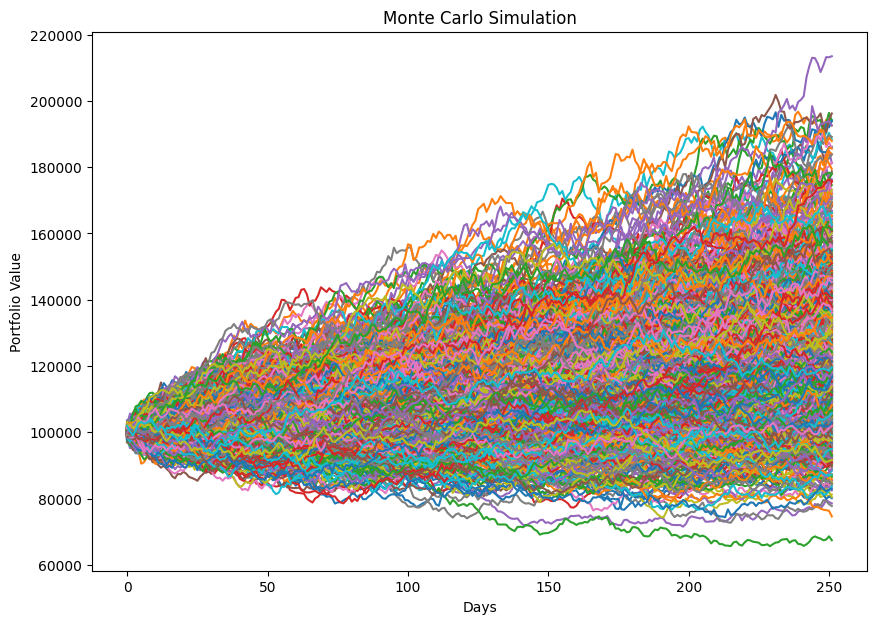

In [12]:
plt.figure(figsize=(10,7))
plt.plot(simulation_results)
plt.title("Monte Carlo Simulation")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.show()

## 📊 Distribution of Final Portfolio Value

This shows the range of possible outcomes after 1 year.

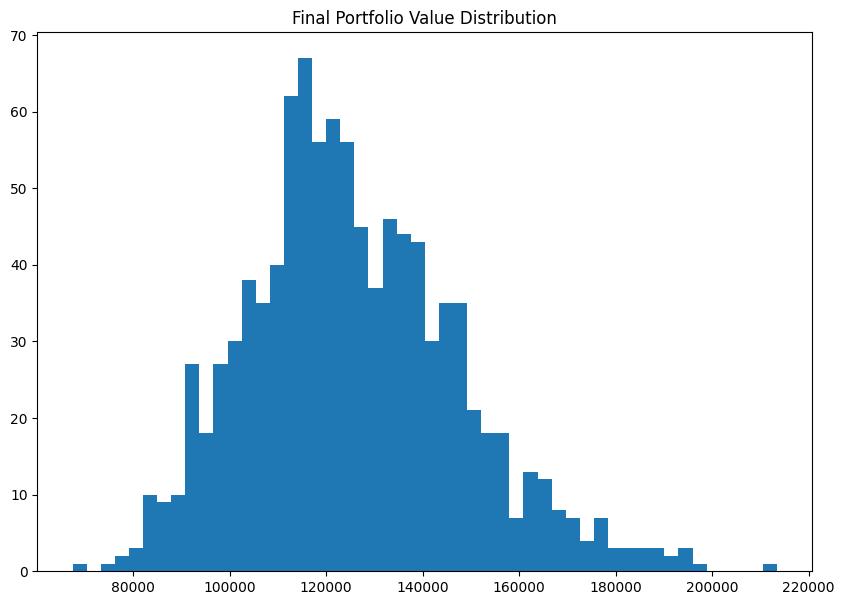

In [13]:
final_values = simulation_results[-1,:]

plt.figure(figsize=(10,7))
plt.hist(final_values, bins=50)
plt.title("Final Portfolio Value Distribution")
plt.show()

## ⚠️ Value-at-Risk (VaR) & Conditional VaR (CVaR)

VaR estimates the worst expected loss at a given confidence level.

CVaR measures the average loss in the worst-case scenarios.

In [14]:
returns_simulated = (final_values - initial_investment) / initial_investment

var_95 = np.percentile(returns_simulated, 5)
cvar_95 = returns_simulated[returns_simulated <= var_95].mean()

print("VaR:", var_95 * initial_investment)
print("CVaR:", cvar_95 * initial_investment)

VaR: -7249.293245723871
CVaR: -13135.379525815804


## 📉 Maximum Drawdown

Maximum Drawdown measures the largest peak-to-trough decline
in portfolio value over time.

In [15]:
portfolio_path = simulation_results[:,0]

running_max = np.maximum.accumulate(portfolio_path)

drawdown = (portfolio_path - running_max) / running_max

max_drawdown = drawdown.min()

print("Maximum Drawdown:", max_drawdown)

Maximum Drawdown: -0.24443211120357874


## 📌 Conclusion

This project demonstrates how quantitative techniques can be applied to build a complete portfolio analytics and risk management framework.

By combining Monte Carlo simulation, Efficient Frontier optimization, Value-at-Risk (VaR), CVaR, and Maximum Drawdown, the model provides a multi-dimensional view of portfolio performance under uncertainty.

Rather than relying solely on expected returns, this approach emphasizes:
- Risk-adjusted decision making  
- Downside risk awareness  
- Probabilistic outcome analysis  

The framework highlights that two portfolios with similar returns can exhibit significantly different risk profiles, reinforcing the importance of comprehensive risk evaluation.

Overall, this project reflects the practical application of mathematical and statistical concepts in finance, and serves as a strong foundation for advanced quantitative modelling, portfolio optimization, and risk analytics.